# California Housing Data - Exploratory Data Analysis
This notebook performs a clean, working EDA for the California housing dataset.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset
Try local first, fallback to remote if missing

In [21]:
from pathlib import Path
import pandas as pd
from src import config

data_path = config.BASE_DIR / config.DATA_PATH

if data_path.exists():
    print("Loading local dataset...")
    df = pd.read_csv(data_path)
else:
    print(f"Local data not found. Downloading from {config.REMOTE_URL}...")
    df = pd.read_csv(config.REMOTE_URL)

df.head()

Loading local dataset...


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Basic Info

In [22]:
print("Dataset shape:", df.shape)
print(df.info())
print(df.describe())

Dataset shape: (20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std   

## Missing Values

In [23]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing)

Missing values per column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


## Histograms

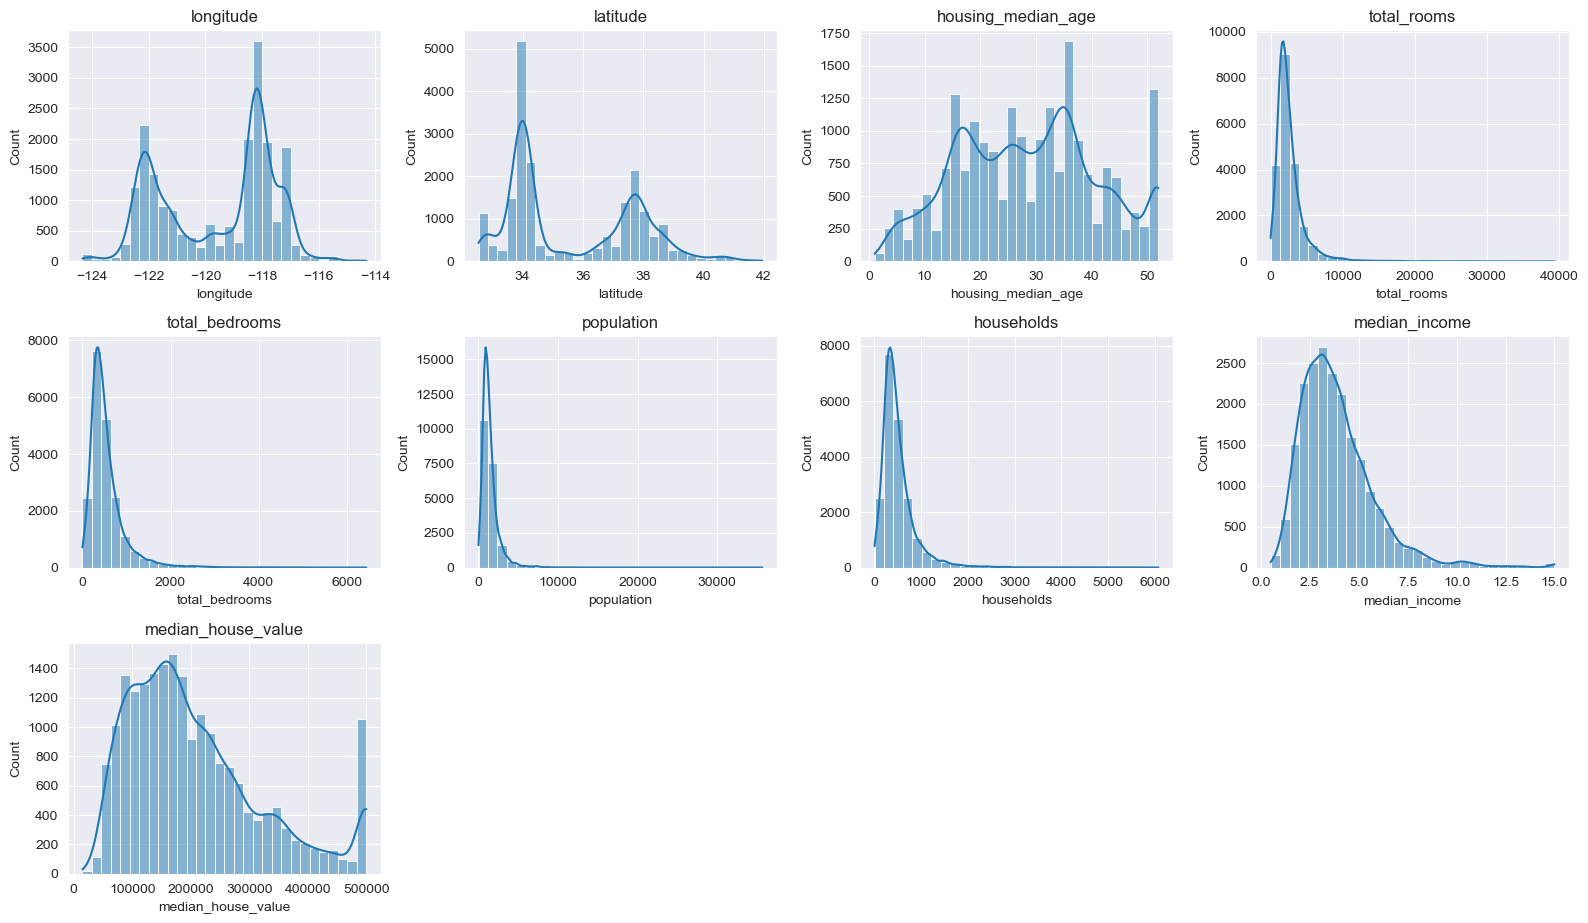

In [24]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_features):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

## Boxplots to detect outliers

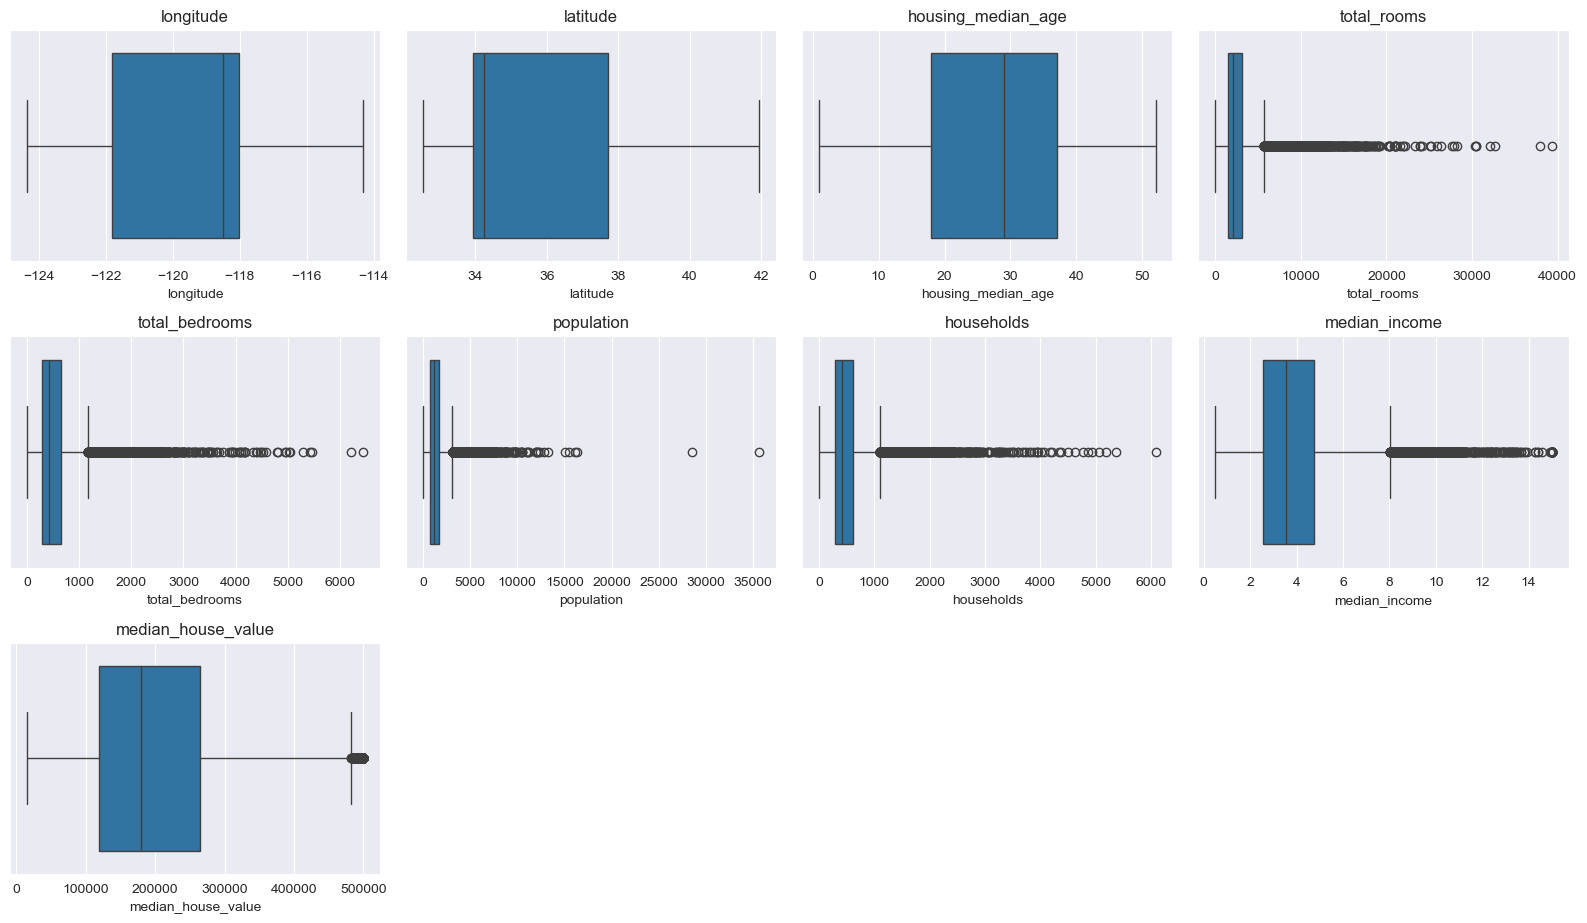

In [25]:
plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_features):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Scatter Plots vs Target

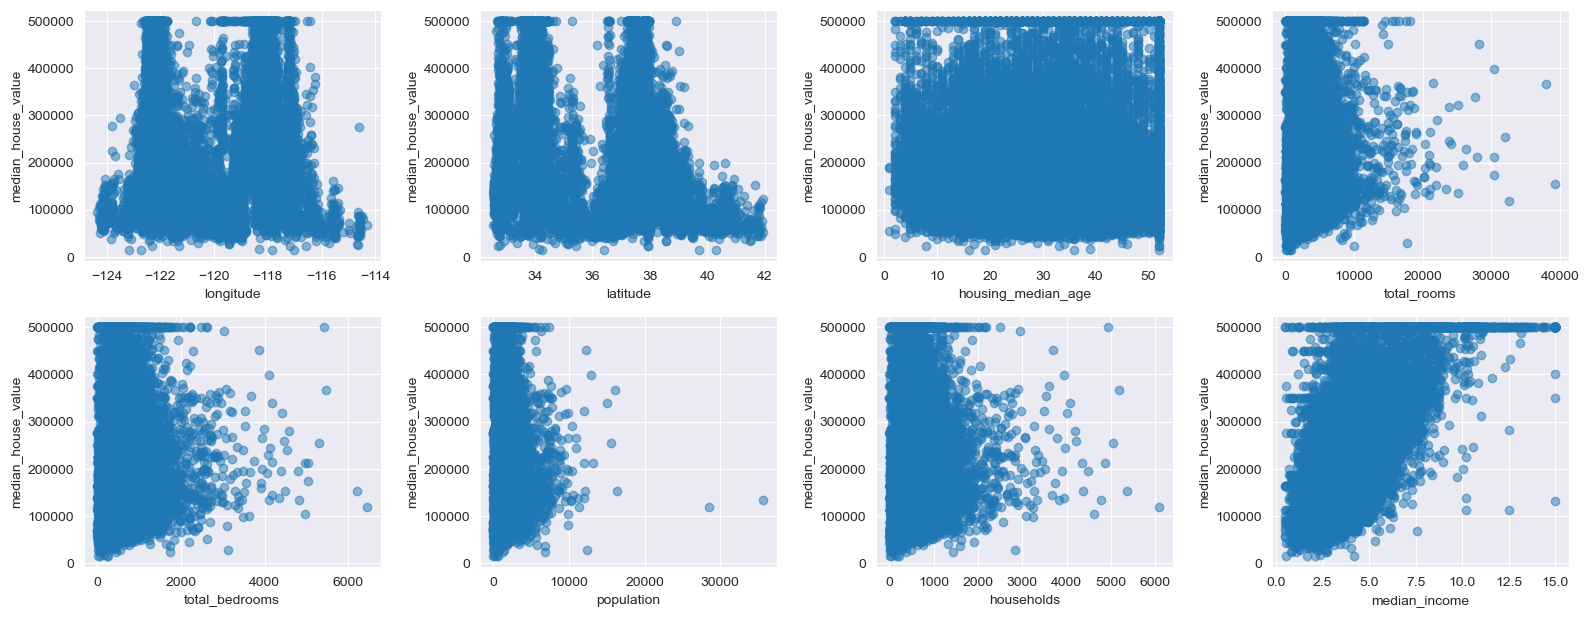

In [26]:
target = config.TARGET
plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_features):
    if col == target:
        continue
    plt.subplot(4, 4, i+1)
    plt.scatter(df[col], df[target], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel(target)
plt.tight_layout()
plt.show()

## Correlation Heatmap

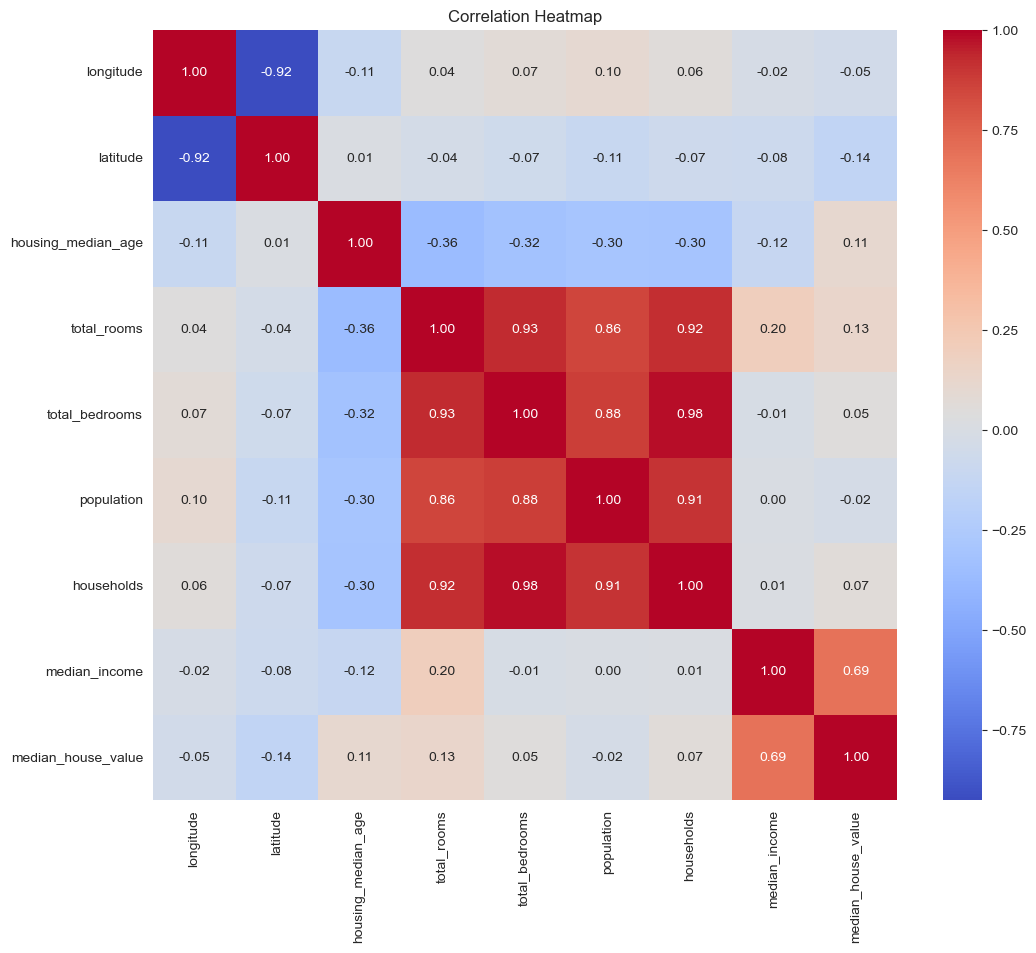

In [27]:
# %% [code]
# Correlation Heatmap (numeric features only)
plt.figure(figsize=(12,10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Categorical Features Analysis

Categorical features: ['ocean_proximity']

Value counts for ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


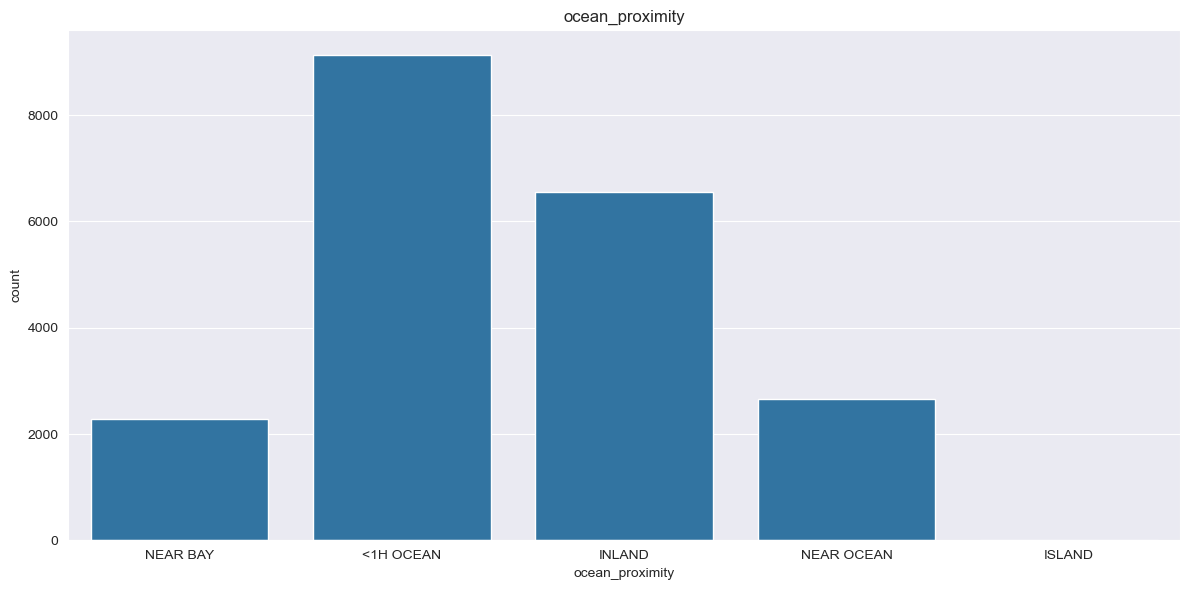

In [28]:
cat_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", cat_features)

for col in cat_features:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

plt.figure(figsize=(12,6))
for i, col in enumerate(cat_features):
    plt.subplot(1, len(cat_features), i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Log Transform Skewed Features (Optional)

Skewed features: ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


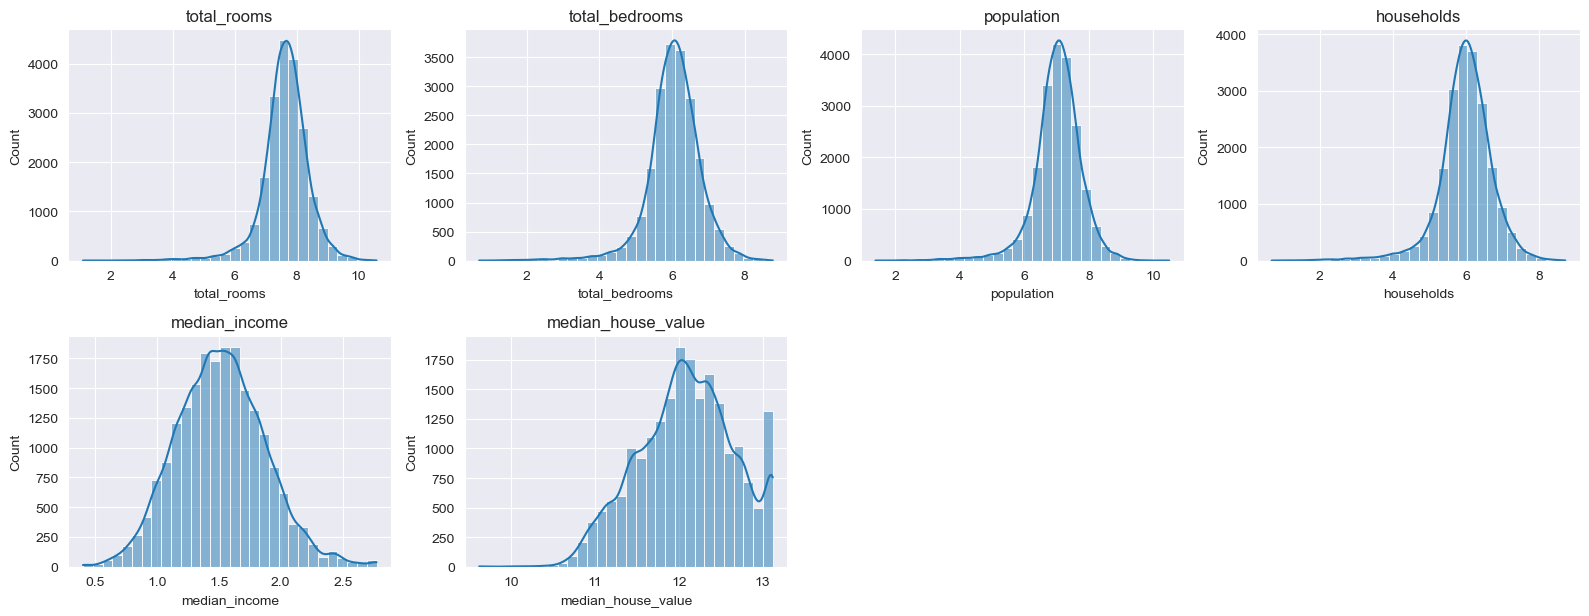

In [29]:
from scipy.stats import skew

skewed_feats = df[numeric_features].apply(lambda x: skew(x.dropna()))
skewed_feats = skewed_feats[abs(skewed_feats) > 0.75].index
print("Skewed features:", list(skewed_feats))

df_log = df.copy()
for feat in skewed_feats:
    df_log[feat] = np.log1p(df_log[feat])

plt.figure(figsize=(16,12))
for i, col in enumerate(skewed_feats):
    plt.subplot(4, 4, i+1)
    sns.histplot(df_log[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Observations & Insights
## 1. Dataset Overview
- The dataset has **20,641 rows** and multiple numeric and categorical features.
- Target variable is `median_house_value`.
- No critical missing values were found, minor missing values can be imputed.
## 2. Numeric Features
- Most numeric features show **right-skewed distributions** (e.g., `median_income`, `population`).
- Log-transforming skewed features can help improve model performance.
## 3. Categorical Features
- Only `ocean_proximity` is categorical.
- Categories are imbalanced but not extreme; one-hot encoding is appropriate.
## 4. Outliers
- Boxplots show some extreme outliers in `housing_median_age`, `total_rooms`, `total_bedrooms`.
- Consider clipping or transforming these features if they affect regression.
## 5. Correlations
- `median_income` shows the **strongest positive correlation** with the target.
- Features like `longitude` and `latitude` also correlate moderately and may help geographically-aware models.
## 6. Next Steps
- Apply log-transform to skewed numeric features.
- Encode categorical features (`ocean_proximity`).
- Normalize or scale numeric features.
- Split dataset into train/test sets before modeling.
- Start building regression models: Linear Regression, Random Forest, XGBoost.